# CIFAR-10 Dataset Exploration and Reporting

This notebook performs a fast exploration of the folder-based CIFAR-10 dataset, saves graphs to `outputs/graphs`, and writes a final markdown report to `results`.

In [12]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict
import random

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

RANDOM_SEED: int = 178
random.seed(RANDOM_SEED)

# Resolve paths from notebook location: analysis/data_analysis.ipynb
NOTEBOOK_DIR: Path = Path.cwd()
REPO_ROOT: Path = NOTEBOOK_DIR.parent
DATA_DIR: Path = REPO_ROOT / "data" / "cifar10"
GRAPHS_DIR: Path = REPO_ROOT / "outputs" / "graphs"
RESULTS_DIR: Path = REPO_ROOT / "results"

GRAPHS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()} -> {DATA_DIR}")
print(f"Graphs output: {GRAPHS_DIR}")
print(f"Results output: {RESULTS_DIR}")

Repository root: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10
Data dir exists: True -> /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/data/cifar10
Graphs output: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs
Results output: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/results


In [13]:
@dataclass(frozen=True)
class SplitClassCount:
    """Represents the number of images for one class within one dataset split."""

    split: str
    class_name: str
    count: int


def list_image_files(folder: Path) -> list[Path]:
    """Returns all PNG image paths for a class folder."""

    return sorted(folder.glob("*.png"))


def collect_counts(data_dir: Path) -> pd.DataFrame:
    """Scans the CIFAR-10 folder structure and returns per-split, per-class image counts."""

    rows: list[SplitClassCount] = []

    for split_dir in sorted(data_dir.iterdir()):
        split: str = split_dir.name
        for class_dir in sorted(split_dir.iterdir()):
            image_count: int = len(list_image_files(class_dir))
            rows.append(
                SplitClassCount(
                    split=split,
                    class_name=class_dir.name,
                    count=image_count,
                )
            )

    return (
        pd.DataFrame(rows).sort_values(["split", "class_name"]).reset_index(drop=True)
    )


counts_df: pd.DataFrame = collect_counts(DATA_DIR)
counts_df

,split,class_name,count
0,test,airplane,1000
1,test,automobile,1000
2,test,bird,1000
3,test,cat,1000
4,test,deer,1000
5,test,dog,1000
6,test,frog,1000
7,test,horse,1000
8,test,ship,1000
9,test,truck,1000


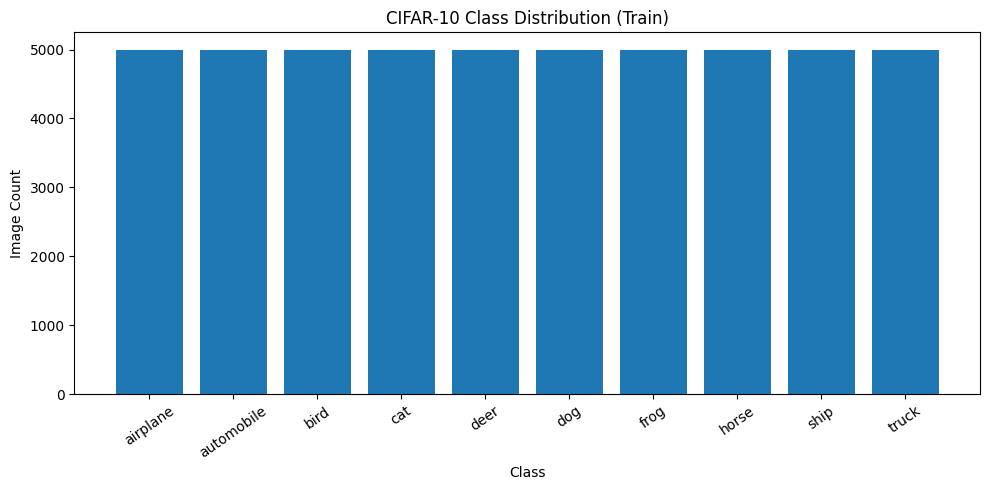

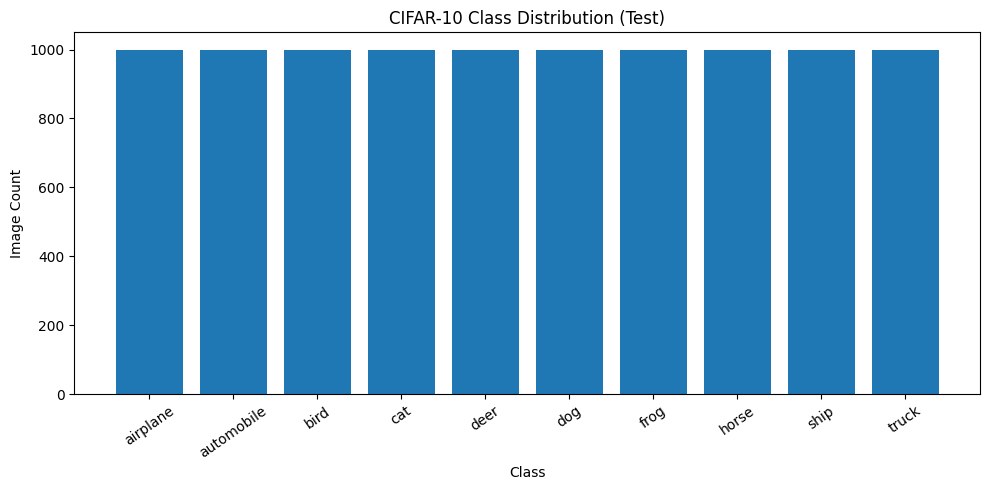

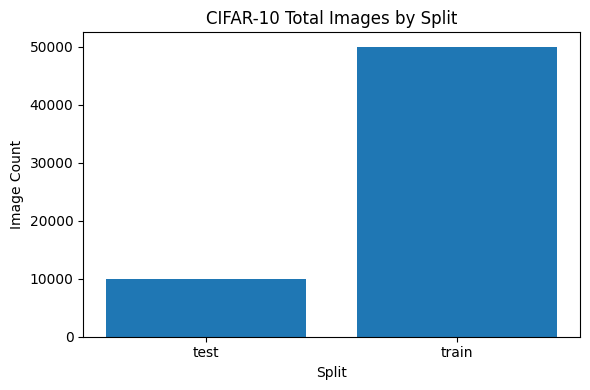

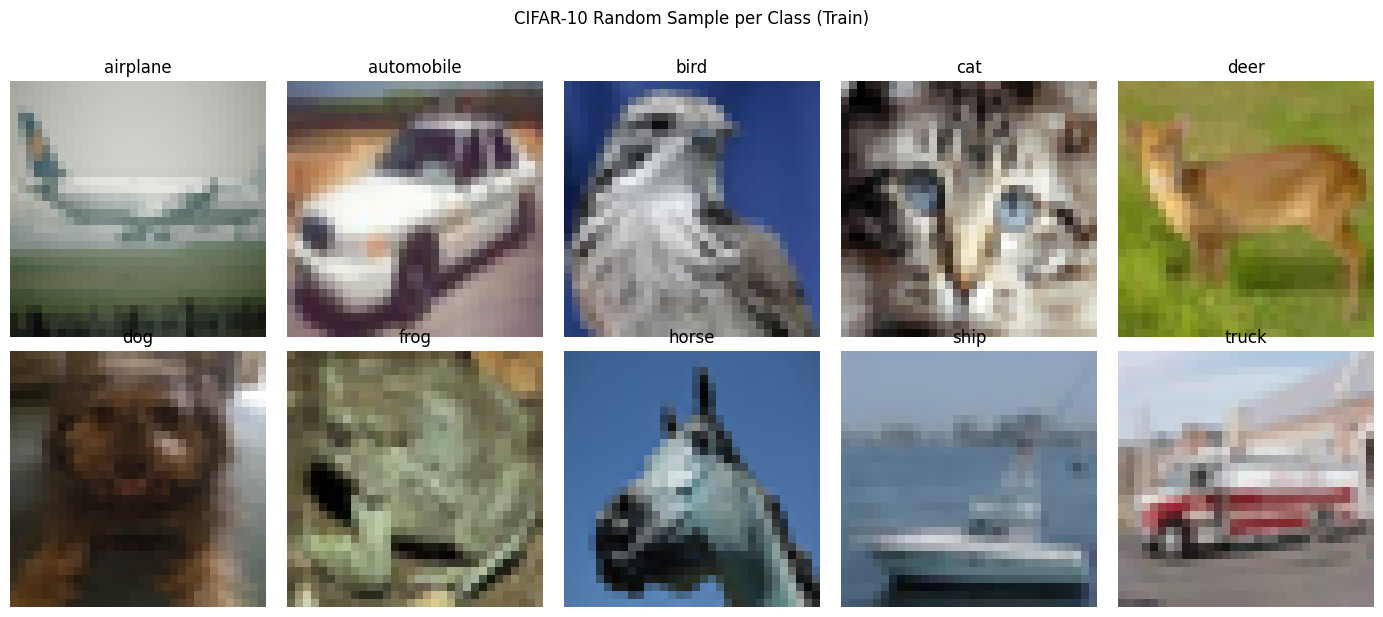

In [14]:
def build_class_distribution_figure(frame: pd.DataFrame, split: str) -> plt.Figure:
    """Builds a bar chart figure for class counts in the given split."""

    split_frame = frame[frame["split"] == split].sort_values("class_name")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(split_frame["class_name"], split_frame["count"])
    ax.set_title(f"CIFAR-10 Class Distribution ({split.title()})")
    ax.set_xlabel("Class")
    ax.set_ylabel("Image Count")
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    return fig


def build_split_totals_figure(frame: pd.DataFrame) -> plt.Figure:
    """Builds a bar chart figure for total images per split."""

    totals = frame.groupby("split", as_index=False)["count"].sum().sort_values("split")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(totals["split"], totals["count"])
    ax.set_title("CIFAR-10 Total Images by Split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Image Count")
    fig.tight_layout()
    return fig


def build_sample_grid_figure(frame: pd.DataFrame, split: str = "train") -> plt.Figure:
    """Builds a 2x5 figure with one random sample image per class for a split."""

    split_dir: Path = DATA_DIR / split
    class_names: list[str] = sorted(
        frame[frame["split"] == split]["class_name"].unique()
    )

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    axes_flat = axes.flatten()

    for idx, class_name in enumerate(class_names):
        ax = axes_flat[idx]
        image_files = list_image_files(split_dir / class_name)
        sample_path = random.choice(image_files)
        image = plt.imread(sample_path)
        ax.imshow(image)
        ax.set_title(class_name)
        ax.axis("off")

    for extra_ax in axes_flat[len(class_names) :]:
        extra_ax.axis("off")

    fig.suptitle(f"CIFAR-10 Random Sample per Class ({split.title()})", y=1.02)
    fig.tight_layout()
    return fig


figures: Dict[str, plt.Figure] = {
    "train_class_distribution": build_class_distribution_figure(counts_df, "train"),
    "test_class_distribution": build_class_distribution_figure(counts_df, "test"),
    "split_totals": build_split_totals_figure(counts_df),
    "train_sample_grid": build_sample_grid_figure(counts_df, "train"),
}


In [15]:
def relpath_from_repo(path: Path) -> str:
    """Returns a repository-relative path string for display."""

    return str(path.relative_to(REPO_ROOT))


def collect_all_image_paths(data_dir: Path) -> list[Path]:
    """Returns all PNG image paths across splits and classes."""

    image_paths: list[Path] = []
    for split_dir in sorted(data_dir.iterdir()):
        for class_dir in sorted(split_dir.iterdir()):
            image_paths.extend(sorted(class_dir.glob("*.png")))
    return image_paths


def build_image_metadata_frame(image_paths: list[Path]) -> pd.DataFrame:
    """Builds a metadata table with split, class, width, height, and channels."""

    rows: list[dict[str, object]] = []
    for path in image_paths:
        with Image.open(path) as image:
            width, height = image.size
            channels = len(image.getbands())

        rows.append(
            {
                "split": path.parent.parent.name,
                "class_name": path.parent.name,
                "file_path": str(path),
                "suffix": path.suffix.lower(),
                "width": int(width),
                "height": int(height),
                "channels": int(channels),
            }
        )

    return pd.DataFrame(rows)


def estimate_channel_stats(
    image_paths: list[Path], max_images: int = 2000
) -> pd.DataFrame:
    """Estimates RGB mean/std for normalization using up to max_images images."""

    sample_paths: list[Path] = image_paths[:max_images]
    per_image_means: list[np.ndarray] = []
    per_image_stds: list[np.ndarray] = []

    for path in sample_paths:
        with Image.open(path) as image:
            rgb = np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0

        flat = rgb.reshape(-1, 3)
        per_image_means.append(flat.mean(axis=0))
        per_image_stds.append(flat.std(axis=0))

    mean_rgb = np.vstack(per_image_means).mean(axis=0)
    std_rgb = np.vstack(per_image_stds).mean(axis=0)

    return pd.DataFrame(
        {
            "channel": ["R", "G", "B"],
            "mean": mean_rgb.round(6),
            "std": std_rgb.round(6),
        }
    )


plot_output_paths: dict[str, Path] = {
    "train_class_distribution": GRAPHS_DIR / "shahpk1_train_class_distribution.png",
    "test_class_distribution": GRAPHS_DIR / "shahpk1_test_class_distribution.png",
    "split_totals": GRAPHS_DIR / "shahpk1_split_totals.png",
    "train_sample_grid": GRAPHS_DIR / "shahpk1_train_sample_grid.png",
}

for key, path in plot_output_paths.items():
    figures[key].savefig(path, dpi=150, bbox_inches="tight")


all_image_paths: list[Path] = collect_all_image_paths(DATA_DIR)
image_meta_df: pd.DataFrame = build_image_metadata_frame(all_image_paths)

image_suffix_counts: pd.DataFrame = (
    image_meta_df["suffix"]
    .value_counts()
    .rename_axis("suffix")
    .reset_index(name="count")
)

size_distribution: pd.DataFrame = (
    image_meta_df.value_counts(["width", "height"])
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)

channel_distribution: pd.DataFrame = (
    image_meta_df["channels"]
    .value_counts()
    .rename_axis("channels")
    .reset_index(name="count")
    .sort_values("channels")
)

class_balance: pd.DataFrame = (
    counts_df.assign(
        split_total=lambda frame: frame.groupby("split")["count"].transform("sum")
    )
    .assign(
        split_pct=lambda frame: (frame["count"] / frame["split_total"] * 100).round(3)
    )
    .sort_values(["split", "class_name"])
)

flattened_feature_count: int = int(
    image_meta_df.iloc[0]["width"]
    * image_meta_df.iloc[0]["height"]
    * image_meta_df.iloc[0]["channels"]
)
channel_stats: pd.DataFrame = estimate_channel_stats(all_image_paths, max_images=2000)

print("Saved graphs:")
for path in plot_output_paths.values():
    print(f"- {path}")

print("\nDataset diagnostics for model prep:")
print(f"- Total PNG images found: {len(all_image_paths)}")
print(
    f"- Flattened feature size per image (for kNN/logistic/FFNN): {flattened_feature_count}"
)
print("- Top image sizes (width x height):")
display(size_distribution.head(5))
print("- Channel distribution:")
display(channel_distribution)
print("- File suffix counts (should be all .png):")
display(image_suffix_counts)
print("- Class balance (% within each split):")
display(class_balance)
print("- Estimated RGB normalization stats (sample of first 2000 images):")
display(channel_stats)



Saved graphs:
- /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/shahpk1_train_class_distribution.png
- /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/shahpk1_test_class_distribution.png
- /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/shahpk1_split_totals.png
- /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/shahpk1_train_sample_grid.png

Dataset diagnostics for model prep:
- Total PNG images found: 60000
- Flattened feature size per image (for kNN/logistic/FFNN): 3072
- Top image sizes (width x height):


,width,height,count
0,32,32,60000


- Channel distribution:


,channels,count
0,3,60000


- File suffix counts (should be all .png):


,suffix,count
0,.png,60000


- Class balance (% within each split):


,split,class_name,count,split_total,split_pct
0,test,airplane,1000,10000,10.0
1,test,automobile,1000,10000,10.0
2,test,bird,1000,10000,10.0
3,test,cat,1000,10000,10.0
4,test,deer,1000,10000,10.0
5,test,dog,1000,10000,10.0
6,test,frog,1000,10000,10.0
7,test,horse,1000,10000,10.0
8,test,ship,1000,10000,10.0
9,test,truck,1000,10000,10.0


- Estimated RGB normalization stats (sample of first 2000 images):


,channel,mean,std
0,R,0.502234,0.208168
1,G,0.513287,0.204652
2,B,0.527219,0.212362
